**Preprocessing of OCTA 2D projection maps (ILM_OPL)**  
*(resizing + denoising + normalization + contrast augmentation)*


Resizing Projection Maps from 400 pixels to 256 pixels

In [20]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 

#Définition du chemin du dossier contenant les images et de la taille cible
data_dir ="C:/Users/hp/OneDrive/Bureau/PRIM/Personal Code/Data/Raw_Data (ILM_OPL)"
output_size = (256, 256)

#Initialisation de la liste pour stocker les images redimensionnées
images = []
filenames = sorted(os.listdir(data_dir))

print(f"Nombre d'images détectées : {len(filenames)}")
print("Début du prétraitement...\n")


for filename in tqdm(filenames, desc="Redimensionnement des cartes OCTA", ncols=80):
    img_path = os.path.join(data_dir, filename)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Fichier illisible ignoré : {filename}")
        continue
    resized_img = cv2.resize(img, output_size, interpolation=cv2.INTER_AREA)
    images.append(resized_img)

# Conversion en tableau NumPy (N × 256 × 256)
images = np.array(images, dtype=np.uint8)

print(f"\nPrétraitement terminé. Dimensions finales du jeu de données : {images.shape}")


images.shape

Nombre d'images détectées : 300
Début du prétraitement...



Redimensionnement des cartes OCTA: 100%|█████| 300/300 [00:01<00:00, 269.45it/s]



Prétraitement terminé. Dimensions finales du jeu de données : (300, 256, 256)


(300, 256, 256)

Filtre Gaussien

Nombre total d'images disponibles : 300
Début de l'application du filtre gaussien...



Application du filtre gaussien: 100%|██████| 300/300 [00:00<00:00, 11838.17it/s]



Filtrage terminé. Affichage d'une image avant et après filtrage.



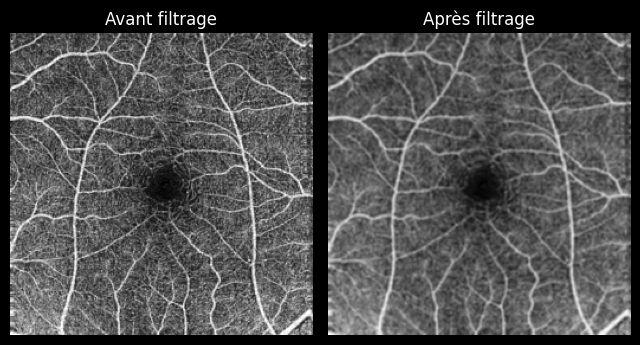

In [ ]:
# Application d'un filtre gaussien sur les images redimensionnées
# Paramètres du filtre : noyau 5x5, écart-type sigma = 0.5
# Description :
# Ce script applique un filtrage gaussien à l’ensemble des images
# déjà redimensionnées (stockées dans la variable "images"),
# puis affiche côte à côte une image avant et après filtrage sans fond blanc.


print(f"Nombre total d'images disponibles : {len(images)}")
print("Début de l'application du filtre gaussien...\n")

filtered_imagesmedian = []

for img in tqdm(images, desc="Application du filtre gaussien", ncols=80):
    filtered = cv2.GaussianBlur(img, (3, 3), sigmaX=1)
    filtered_imagesmedian.append(filtered)

filtered_imagesmedian = np.array(filtered_imagesmedian, dtype=np.uint8)

print("\nFiltrage terminé. Affichage d'une image avant et après filtrage.\n")

# Sélection d'une image (exemple : image 10001)
index = 0

# Création d'une figure sans fond blanc
fig, axes = plt.subplots(1, 2, figsize=(8, 4), facecolor='black')

axes[0].imshow(images[index], cmap='gray')
axes[0].set_title(f"Avant filtrage", color='white', fontsize=12)
axes[0].axis('off')

axes[1].imshow(filtered_imagesmedian[index], cmap='gray')
axes[1].set_title(f"Après filtrage", color='white', fontsize=12)
axes[1].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0)
plt.show()


Calcul du SNR Moyen du dataset avant et après filtrage

In [ ]:
#Calcul du SNR local moyen avant et après filtrage gaussien
#Chaque image possède sa propre région d'intérêt (ROI) homogène,
#déterminée automatiquement à partir de la variance locale.


# Fonction de calcul du SNR (en dB)
def compute_snr(image):
    mean_val = np.mean(image)
    std_val = np.std(image)
    if std_val == 0:
        return 0
    return 10 * np.log10((mean_val ** 2) / (std_val ** 2))

# Détection automatique d'une région homogène (faible variance)
def find_homogeneous_roi(img, window_size=20, stride=10):
    h, w = img.shape
    min_std = float('inf')
    best_roi = (0, 0, window_size, window_size)
    
    # balayage de l'image par fenêtres glissantes
    for y in range(0, h - window_size, stride):
        for x in range(0, w - window_size, stride):
            patch = img[y:y+window_size, x:x+window_size]
            patch_std = np.std(patch)
            if patch_std < min_std:
                min_std = patch_std
                best_roi = (x, y, window_size, window_size)
    return best_roi

# Listes pour stocker les SNR
snr_before = []
snr_after = []

print("Début du calcul du SNR local (chaque image possède sa propre ROI)...\n")

# Boucle sur toutes les images
for i in tqdm(range(len(images)), desc="Analyse SNR local", ncols=80):
    img_before = images[i]
    img_after = filtered_imagesmedian[i]
    
    # Trouver la ROI la plus homogène sur l'image avant filtrage
    x, y, w, h = find_homogeneous_roi(img_before, window_size=20, stride=10)
    
    # Extraire la même zone avant et après filtrage
    roi_before = img_before[y:y+h, x:x+w]
    roi_after = img_after[y:y+h, x:x+w]
    
    # Calcul du SNR local pour cette image
    snr_before.append(compute_snr(roi_before))
    snr_after.append(compute_snr(roi_after))

# Moyenne sur l'ensemble du jeu de données
mean_snr_before = np.mean(snr_before)
mean_snr_after = np.mean(snr_after)

print(f"SNR moyen (local) avant filtrage  : {mean_snr_before:.2f} dB")
print(f"SNR moyen (local) après filtrage  : {mean_snr_after:.2f} dB")
print(f"Amélioration moyenne du SNR local : {mean_snr_after - mean_snr_before:.2f} dB")


Début du calcul du SNR local (chaque image possède sa propre ROI)...



Analyse SNR local: 100%|█████████████████████| 300/300 [00:02<00:00, 114.61it/s]

SNR moyen (local) avant filtrage  : 5.30 dB
SNR moyen (local) après filtrage  : 8.43 dB
Amélioration moyenne du SNR local : 3.13 dB


Filtre médian

Nombre total d'images disponibles : 300
Début de l'application du filtre médian...



Application du filtre médian: 100%|████████| 300/300 [00:00<00:00, 15289.64it/s]


Filtrage terminé. Affichage d'une image avant et après filtrage.



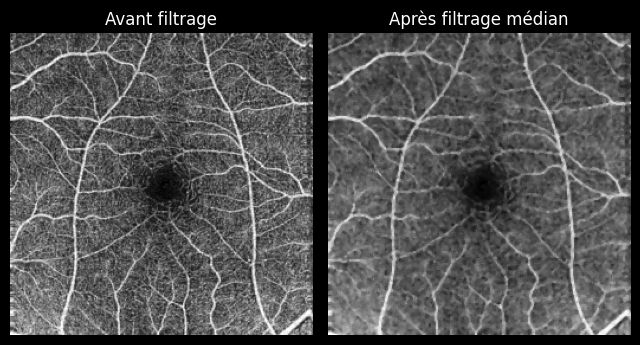

In [ ]:
# Application d'un filtre médian sur les images redimensionnées
# Paramètres du filtre : noyau 3x3
# Description :
# Ce script applique un filtrage médian à l’ensemble des images
# déjà redimensionnées (stockées dans la variable "images"),
# puis affiche côte à côte une image avant et après filtrage sans fond blanc.


print(f"Nombre total d'images disponibles : {len(images)}")
print("Début de l'application du filtre médian...\n")

filtered_imagesmedian = []

# Application du filtre médian à chaque image
for img in tqdm(images, desc="Application du filtre médian", ncols=80):
    filtered = cv2.medianBlur(img, 3)  # taille du noyau = 3
    filtered_imagesmedian.append(filtered)

filtered_imagesmedian = np.array(filtered_imagesmedian, dtype=np.uint8)

print("\nFiltrage terminé. Affichage d'une image avant et après filtrage.\n")

# Sélection d'une image (exemple : image 10001)
index = 0

# Création d'une figure sans fond blanc
fig, axes = plt.subplots(1, 2, figsize=(8, 4), facecolor='black')

axes[0].imshow(images[index], cmap='gray')
axes[0].set_title("Avant filtrage", color='white', fontsize=12)
axes[0].axis('off')

axes[1].imshow(filtered_imagesmedian[index], cmap='gray')
axes[1].set_title("Après filtrage médian", color='white', fontsize=12)
axes[1].axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0)
plt.show()


In [ ]:
# Calcul du SNR local moyen avant et après filtrage médian
# Chaque image possède sa propre ROI homogène détectée automatiquement

# Fonction de calcul du SNR (en dB)
def compute_snr(image):
    mean_val = np.mean(image)
    std_val = np.std(image)
    if std_val == 0:
        return 0
    return 10 * np.log10((mean_val ** 2) / (std_val ** 2))

# Fonction pour trouver une région homogène (faible variance)
def find_homogeneous_roi(img, window_size=20, stride=10):
    h, w = img.shape
    min_std = float('inf')
    best_roi = (0, 0, window_size, window_size)
    for y in range(0, h - window_size, stride):
        for x in range(0, w - window_size, stride):
            patch = img[y:y+window_size, x:x+window_size]
            patch_std = np.std(patch)
            if patch_std < min_std:
                min_std = patch_std
                best_roi = (x, y, window_size, window_size)
    return best_roi

# Listes pour stocker les valeurs de SNR
snr_before = []
snr_after = []

print("Début du calcul du SNR local (ROI spécifique à chaque image) pour le filtre médian...\n")

# Boucle sur toutes les images
for i in tqdm(range(len(images)), desc="Calcul SNR local", ncols=80):
    img_before = images[i]
    img_after = filtered_images_median[i]
    
    # Trouver la ROI homogène sur l'image avant filtrage
    x, y, w, h = find_homogeneous_roi(img_before, window_size=20, stride=10)
    
    # Extraire la même ROI avant et après filtrage
    roi_before = img_before[y:y+h, x:x+w]
    roi_after = img_after[y:y+h, x:x+w]
    
    # Calcul du SNR local sur la ROI
    snr_before.append(compute_snr(roi_before))
    snr_after.append(compute_snr(roi_after))

# Moyenne sur l'ensemble du jeu de données
mean_snr_before = np.mean(snr_before)
mean_snr_after = np.mean(snr_after)

print(f"SNR moyen (local) avant filtrage médian  : {mean_snr_before:.2f} dB")
print(f"SNR moyen (local) après filtrage médian  : {mean_snr_after:.2f} dB")
print(f"Amélioration moyenne du SNR local (médian) : {mean_snr_after - mean_snr_before:.2f} dB")


Début du calcul du SNR local (ROI spécifique à chaque image) pour le filtre médian...



Calcul SNR local: 100%|██████████████████████| 300/300 [00:02<00:00, 114.95it/s]

SNR moyen (local) avant filtrage médian  : 5.30 dB
SNR moyen (local) après filtrage médian  : 8.34 dB
Amélioration moyenne du SNR local (médian) : 3.04 dB


Nombre total d'images : 300
Début de la détection des petits vaisseaux avec le filtre de Frangi (sans CLAHE ni normalisation)...



Application du filtre de Frangi (petits vaisseaux):   0%| | 0/300 [00:00<?, ?it/C:\Users\hp\AppData\Local\Temp\ipykernel_9584\1387170033.py:14: UserWarning: Use keyword parameter `sigmas` instead of `scale_range` and `scale_range` which will be removed in version 0.17.
  vessels = frangi(
Application du filtre de Frangi (petits vaisseaux): 100%|█| 300/300 [03:00<00:00



Traitement terminé. Visualisation d'une image exemple...



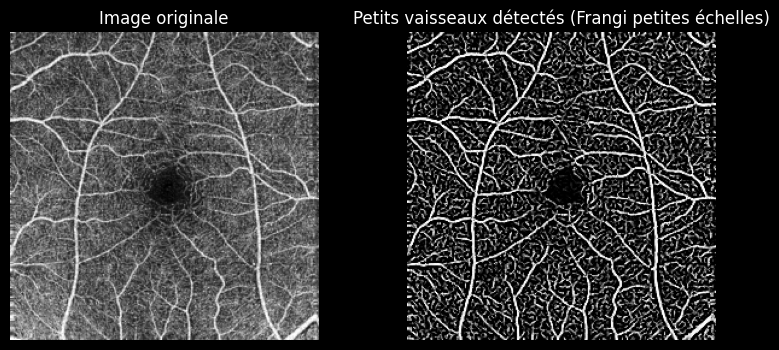

In [22]:
# Détection et visualisation des petits vaisseaux sanguins (capillaires)
# à l'aide du filtre de Frangi ajusté sur les petites échelles
# Appliqué directement sur les images redimensionnées (variable 'images')
# Sans CLAHE ni normalisation préalable

from skimage.filters import frangi
from skimage import exposure

def frangi_small_vessels(img_uint8):
    # Conversion en float32 pour compatibilité avec le filtre Frangi
    img_float = img_uint8.astype(np.float32)
    
    # Application du filtre de Frangi sur de petites échelles
    vessels = frangi(
        img_float,
        scale_range=(0.6, 1.6),   # petites échelles : capillaires
        scale_step=0.2,
        alpha=0.5,
        beta=0.5,
        gamma=12,
        black_ridges=False        # vaisseaux clairs sur fond sombre
    )

    # Remplacement des NaN éventuels
    vessels = np.nan_to_num(vessels)

    # Normalisation simple pour affichage (sans rescale global)
    if np.max(vessels) > 0:
        vessels_norm = vessels / np.max(vessels)
    else:
        vessels_norm = vessels

    # Conversion en 8 bits pour visualisation
    vessels_8bit = (vessels_norm * 255).astype(np.uint8)

    return vessels_8bit


print(f"Nombre total d'images : {len(images)}")
print("Début de la détection des petits vaisseaux avec le filtre de Frangi (sans CLAHE ni normalisation)...\n")

filtered_images_frangi_small = []

for img in tqdm(images, desc="Application du filtre de Frangi (petits vaisseaux)", ncols=80):
    small_vessels = frangi_small_vessels(img)
    filtered_images_frangi_small.append(small_vessels)

filtered_images_frangi_small = np.array(filtered_images_frangi_small, dtype=np.uint8)

print("\nTraitement terminé. Visualisation d'une image exemple...\n")

# Affichage d'une image avant et après filtrage
index = 0  # exemple : image 10001

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='black')

axes[0].imshow(images[index], cmap='gray')
axes[0].set_title("Image originale", color='white', fontsize=12)
axes[0].axis('off')

axes[1].imshow(filtered_images_frangi_small[index], cmap='gray')
axes[1].set_title("Petits vaisseaux détectés (Frangi petites échelles)", color='white', fontsize=12)
axes[1].axis('off')

plt.subplots_adjust(wspace=0.05)
plt.show()


Nombre total d'images : 300
Début du filtrage Gabor pour petits vaisseaux...



Application des filtres de Gabor: 100%|███████| 300/300 [00:06<00:00, 49.54it/s]



Traitement terminé. Visualisation d'une image exemple...



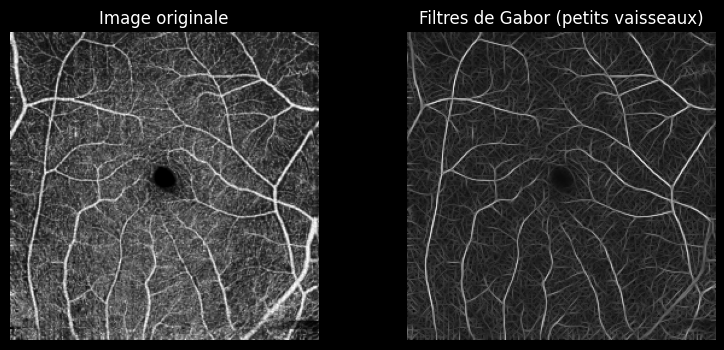

In [6]:
# Détection des petits vaisseaux avec une banque de filtres de Gabor
# Appliqué directement sur les images originales redimensionnées (variable "images")
# Sans normalisation préalable


def gabor_vessel_enhancement(img_uint8, thetas, lambd=4.0, sigma=2.0, gamma=0.5):
    """
    Applique une banque de filtres de Gabor à plusieurs orientations pour mettre en évidence
    les structures tubulaires fines (petits vaisseaux).
    Paramètres :
        img_uint8 : image en niveaux de gris (uint8)
        thetas : liste d'angles (en radians)
        lambd : longueur d'onde de la composante sinusoïdale
        sigma : écart-type de l’enveloppe gaussienne
        gamma : rapport d’aspect de la gaussienne
    Retour :
        Image rehaussée (uint8)
    """
    img = img_uint8.astype(np.float32)
    responses = []

    for theta in thetas:
        kernel = cv2.getGaborKernel(
            ksize=(9, 9),       # taille du noyau (petite -> capillaires)
            sigma=sigma,        # largeur de la gaussienne
            theta=theta,        # orientation
            lambd=lambd,        # fréquence spatiale
            gamma=gamma,        # rapport d’aspect (0.5 = allongé)
            psi=0,              # phase
            ktype=cv2.CV_32F
        )
        filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
        responses.append(filtered)

    # Combinaison par maximum sur les orientations
    vesselness = np.max(responses, axis=0)

    # Mise à l’échelle locale (0–255)
    vesselness = vesselness - np.min(vesselness)
    if np.max(vesselness) > 0:
        vesselness = vesselness / np.max(vesselness) * 255

    return vesselness.astype(np.uint8)


print(f"Nombre total d'images : {len(images)}")
print("Début du filtrage Gabor pour petits vaisseaux...\n")

filtered_images_gabor = []

# Orientations testées (0 à 180°)
thetas = np.linspace(0, np.pi, 12, endpoint=False)

# Paramètres adaptés aux capillaires
lambd = 3.5   # petite longueur d’onde = structures fines
sigma = 1.75   # largeur de gaussienne
gamma = 0.5   # forme allongée

for img in tqdm(images, desc="Application des filtres de Gabor", ncols=80):
    vessels = gabor_vessel_enhancement(img, thetas, lambd, sigma, gamma)
    filtered_images_gabor.append(vessels)

filtered_images_gabor = np.array(filtered_images_gabor, dtype=np.uint8)

print("\nTraitement terminé. Visualisation d'une image exemple...\n")

# Visualisation d'une image avant/après
index = 1 # exemple : image 10001

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='black')

axes[0].imshow(images[index], cmap='gray')
axes[0].set_title("Image originale", color='white', fontsize=12)
axes[0].axis('off')

axes[1].imshow(filtered_images_gabor[index], cmap='gray')
axes[1].set_title("Filtres de Gabor (petits vaisseaux)", color='white', fontsize=12)
axes[1].axis('off')

plt.subplots_adjust(wspace=0.05)
plt.show()


Nombre total d'images : 300
Début de l'amélioration post-Gabor (CLAHE + normalisation)...



Application CLAHE + Normalisation: 100%|████| 300/300 [00:00<00:00, 4127.63it/s]



Traitement terminé. Visualisation d'une image exemple...



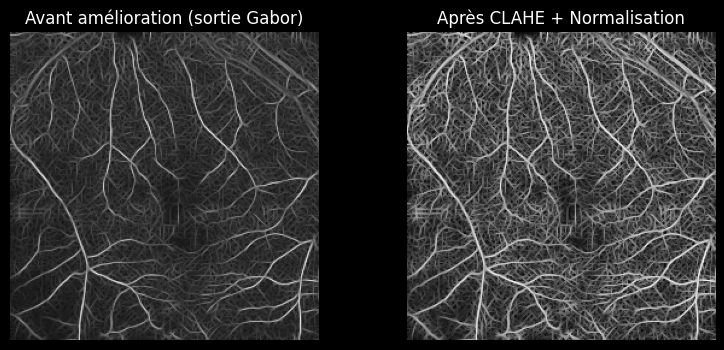

In [ ]:


def enhance_contrast_clahe_norm(img_uint8, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Applique d'abord CLAHE, puis une normalisation min-max sur l'image.
    Paramètres :
        img_uint8 : image 2D en uint8
        clip_limit : limite de contraste local pour CLAHE
        tile_grid_size : taille des sous-blocs CLAHE
    Retour :
        image améliorée (uint8)
    """
    # Étape 1 : CLAHE (amélioration locale du contraste)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    img_clahe = clahe.apply(img_uint8)

    # Étape 2 : Normalisation min-max en [0, 255]
    img_norm = cv2.normalize(img_clahe, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

    return img_norm.astype(np.uint8)


print(f"Nombre total d'images : {len(filtered_images_gabor)}")
print("Début de l'amélioration post-Gabor (CLAHE + normalisation)...\n")

enhanced_images_gabor = []

for img in tqdm(filtered_images_gabor, desc="Application CLAHE + Normalisation", ncols=80):
    enhanced = enhance_contrast_clahe_norm(img, clip_limit=2.0, tile_grid_size=(8, 8))
    enhanced_images_gabor.append(enhanced)

enhanced_images_gabor = np.array(enhanced_images_gabor, dtype=np.uint8)

print("\nTraitement terminé. Visualisation d'une image exemple...\n")

# Visualisation d'une image avant/après
index = 1  # exemple : image 10002

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='black')

axes[0].imshow(filtered_images_gabor[index], cmap='gray')
axes[0].set_title("Avant amélioration (sortie Gabor)", color='white', fontsize=12)
axes[0].axis('off')

axes[1].imshow(enhanced_images_gabor[index], cmap='gray')
axes[1].set_title("Après CLAHE + Normalisation", color='white', fontsize=12)
axes[1].axis('off')

plt.subplots_adjust(wspace=0.05)
plt.show()


Nombre total d'images : 300
Début de l'amélioration post-Frangi (CLAHE + normalisation)...



Application CLAHE + Normalisation: 100%|████| 300/300 [00:00<00:00, 4396.90it/s]


Traitement terminé. Visualisation d'une image exemple...



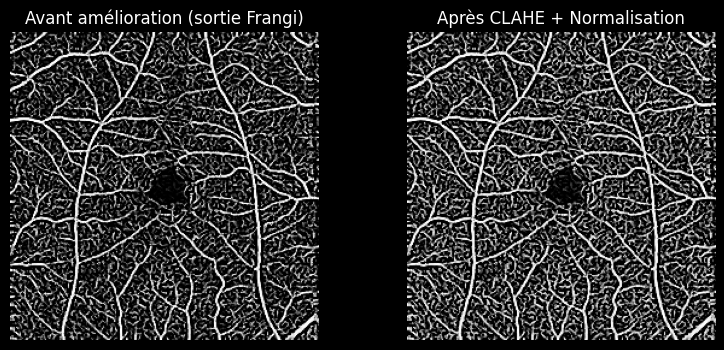

In [4]:


def enhance_contrast_clahe_norm(img_uint8, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Applique d'abord CLAHE, puis une normalisation min-max sur l'image.
    Paramètres :
        img_uint8 : image 2D en uint8
        clip_limit : limite du contraste local pour CLAHE
        tile_grid_size : taille des sous-blocs pour CLAHE
    Retour :
        image améliorée (uint8)
    """
    # 1) CLAHE (amélioration locale du contraste)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    img_clahe = clahe.apply(img_uint8)

    # 2) Normalisation globale en [0, 255]
    img_norm = cv2.normalize(img_clahe, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

    return img_norm.astype(np.uint8)


print(f"Nombre total d'images : {len(filtered_images_frangi_small)}")
print("Début de l'amélioration post-Frangi (CLAHE + normalisation)...\n")

enhanced_images_frangi = []

for img in tqdm(filtered_images_frangi_small, desc="Application CLAHE + Normalisation", ncols=80):
    enhanced = enhance_contrast_clahe_norm(img, clip_limit=2.0, tile_grid_size=(8, 8))
    enhanced_images_frangi.append(enhanced)

enhanced_images_frangi = np.array(enhanced_images_frangi, dtype=np.uint8)

print("\nTraitement terminé. Visualisation d'une image exemple...\n")

# Visualisation d'une image avant/après
index = 0  # exemple : image 10001

fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor='black')

axes[0].imshow(filtered_images_frangi_small[index], cmap='gray')
axes[0].set_title("Avant amélioration (sortie Frangi)", color='white', fontsize=12)
axes[0].axis('off')

axes[1].imshow(enhanced_images_frangi[index], cmap='gray')
axes[1].set_title("Après CLAHE + Normalisation", color='white', fontsize=12)
axes[1].axis('off')

plt.subplots_adjust(wspace=0.05)
plt.show()
